In [1]:
%run notebook_setup.py

import pandas as pd
import numpy as np
from scipy.stats import trim_mean
import polars as pl
import pandas as pd
import logging
import gc
from pathlib import Path
import glob
import math

import matplotlib.pyplot as plt
import seaborn as sns

from src.config.dir_config import OUTPUT_PATH_DEMAND_SUMMARY
from src.config.bigquery_config import CREDENTIALS_GBQ, PROJECT_ID_GBQ
from src.utils.read_data import read_data
from src.utils.setup_logging import setup_logging
from src.utils.create_week_date import add_week_start_date
from src.utils.export_as_excel import export_dataframes_as_tables




import logging

setup_logging()

Now you can import modules from the project root: /bi/workspace/Projects/Forecast/forecast


In [2]:
import polars as pl
from pathlib import Path

def load_maestro_producto(refresh: bool = False) -> pl.LazyFrame:
    BASE = Path("../data/raw")
    MP_PATH = BASE / "maestro_producto.parquet"

    if refresh:
        query = """
            SELECT
                *
            FROM `bold-momentum-270218.pbi_data.maestro_sku_procesado`
            WHERE CAST(ano_temporada AS INT64) >= 2015
        """
        df = read_data(query=query, credentials=CREDENTIALS_GBQ, project_id=PROJECT_ID_GBQ)
        MP_PATH.parent.mkdir(parents=True, exist_ok=True)
        df.to_parquet(MP_PATH, compression="zstd")

    if not MP_PATH.exists():
        raise FileNotFoundError(f"No existe {MP_PATH}. Ejecuta con refresh=True al menos una vez.")

    mp_lf = (
        pl.scan_parquet(str(MP_PATH))
        .with_columns(
            pl.col("cod_talla").cast(pl.UInt16),
            pl.col("nom_talla").cast(pl.Categorical),
            pl.col("cod_producto").cast(pl.Utf8),
            pl.col("cod_depto").cast(pl.Int32),
            pl.col("cod_linea").cast(pl.Int32),
            pl.col("cod_grupo").cast(pl.Int32),
            pl.col("cod_marca").cast(pl.Int32),
            pl.col("cod_division").cast(pl.Int32),
            pl.col("cod_temporada").cast(pl.Int32),
            pl.col("ano_temporada").cast(pl.Int16),
            pl.col("nombre_depto").cast(pl.Categorical),
            pl.col("nombre_linea").cast(pl.Categorical),
            pl.col("nombre_grupo").cast(pl.Categorical),
            pl.col("nombre_marca").cast(pl.Categorical),
            pl.col("nombre_division").cast(pl.Categorical),
            pl.col("nombre_temporada").cast(pl.Categorical),
        )
        .select([
            "cod_producto",
            "cod_talla","nom_talla",
            "cod_depto","nombre_depto",
            "cod_linea","nombre_linea",
            "cod_grupo","nombre_grupo",
            "cod_marca","nombre_marca",
            "cod_division","nombre_division",
            "cod_temporada","nombre_temporada",
            "ano_temporada",
        ])
    )
    return mp_lf

In [3]:
from pathlib import Path
import polars as pl

base_path = Path("../data/processed/weekly_sales_by_season")
seasons = ["Invierno"]
years = {"2022","2023", "2024", "2025"}

paths = []
for season in seasons:
    season_path = base_path / season
    for file in season_path.glob("*.parquet"):
        if any(year in file.name for year in years):
            paths.append(str(file))

if not paths:
    raise ValueError("No se encontraron archivos para las temporadas y años indicados.")

data_sales_raw = pl.scan_parquet(paths).with_columns(pl.col("cod_producto").cast(pl.Utf8))

In [4]:
data_sales = data_sales_raw.join(
        load_maestro_producto(refresh=False),
        on=["cod_producto", "cod_talla"],
        how="left",)

In [5]:
data_sales = data_sales.with_columns(
    (
        pl.datetime(pl.col("cod_ano_comercial"), 1, 4)  # 4 de enero → semana ISO 1
        .dt.truncate("1w")                              # bajar al lunes
        + (pl.col("cod_semana") - 1) * pl.duration(weeks=1)
    ).alias("week_start_date")
)

In [6]:
sample = data_sales.collect()

# Forecast

In [7]:
TARGET_VARIABLE = "weekly_sales"

## Sube un nivel para ventas correctas

In [8]:
data_sales = (
    sample
    .group_by(
        [
            "cod_temporada", "nombre_temporada", "ano_temporada",
            "cod_depto", "nombre_depto",
            "cod_linea", "nombre_linea",
            "cod_talla",
            "cod_sucursal",
            "cod_ano_comercial",
            "cod_semana",
            "week_start_date",
        ]
    )
    .agg(
        pl.col("flag_inventory_available").sum().alias("n_skus_with_inventory"),
        pl.col("flag_without_first_sale").sum().alias("n_skus_without_first_sale"),
        pl.col("flag_sku_arrival").sum().alias("n_skus_arrival"),
        pl.col("stock_start_week").sum().alias("stock_start_week"),
        pl.col("stock_end_week").sum().alias("stock_end_week"),
        pl.col("weekly_available_stock").sum().alias("weekly_available_stock"),
        pl.col("weekly_sales").sum().alias("weekly_sales"),
        pl.col(TARGET_VARIABLE).sum().alias(TARGET_VARIABLE),
        (pl.col("stock_start_week") * pl.col("mnt_precio_vigente")).sum().alias("sum_stock_price"),
    )
    .with_columns(
        (pl.col("sum_stock_price") / pl.col("stock_start_week")).alias("precio_ponderado")
    )
    .drop("sum_stock_price")  # opcional, para dejar solo el final
    .sort(
        by=[
            "cod_temporada", "nombre_temporada", "ano_temporada",
            "cod_depto", "nombre_depto",
            "cod_linea", "nombre_linea",
            "cod_talla",
            "cod_sucursal",
            "cod_ano_comercial",
            "cod_semana",
        ]
    )
)


DuplicateError: column with name 'weekly_sales' has more than one occurrence

Resolved plan until failure:

	---> FAILED HERE RESOLVING 'sink' <---
DF ["cod_sucursal", "cod_producto", "cod_talla", "cod_sku", ...]; PROJECT */44 COLUMNS

# Ingenieria de variables

In [ ]:
import polars as pl
import numpy as np

# --- Ciclo anual (sin/cos) ---
data_sales = data_sales.with_columns([
    (np.sin(2 * np.pi * pl.col("cod_semana") / 52)).alias("semana_sin"),
    (np.cos(2 * np.pi * pl.col("cod_semana") / 52)).alias("semana_cos"),
])

# --- Calendario ---
data_sales = data_sales.with_columns([
    pl.col("week_start_date").dt.month().alias("mes"),
    (((pl.col("week_start_date").dt.month() - 1) // 3) + 1).alias("trimestre")
])

# --- Orden temporal ---
keys = ["cod_sucursal", "cod_talla"]
sort_keys = [
    "cod_temporada", "ano_temporada",
    "cod_depto", "cod_linea",
    "cod_talla", "cod_sucursal",
    "week_start_date",
]
data_sales = data_sales.sort(sort_keys)

# --- Lags ---
for w in [1, 2, 3, 4, 8, 12]:
    data_sales = data_sales.with_columns(
        pl.col("weekly_sales").shift(w).over(keys).alias(f"lag_{w}")
    )

# --- Rolling mean/std (con shift para no mirar semana actual) ---
for w in [4, 8, 12]:
    data_sales = data_sales.with_columns([
        pl.col("weekly_sales")
        .rolling_mean(window_size=w, min_periods=2)
        .shift(1)
        .over(keys)
        .alias(f"rmean_{w}"),

        pl.col("weekly_sales")
        .rolling_std(window_size=w, min_periods=2)
        .shift(1)
        .over(keys)
        .alias(f"rstd_{w}")
    ])

# --- Momentum ---
data_sales = data_sales.with_columns(
    (pl.col("rmean_4") / pl.col("rmean_12")).alias("momentum_4_12")
)

# --- Calcular week_end_date ---
data_sales = data_sales.with_columns(
    (pl.col("week_start_date") + pl.duration(days=6)).alias("week_end_date")
)

# --- is_payday ---
# Función vectorizada: calculamos si week_start_date o week_end_date caen en la ventana
# (últimos 2 hábiles del mes o primeros 5 hábiles del siguiente)
def calc_is_payday(df: pl.DataFrame) -> pl.Series:
    result = []
    for start, end in zip(df["week_start_date"], df["week_end_date"]):
        dias = pl.date_range(start, end, interval="1d", eager=True)
        flag = False
        for d in dias:
            # Último día del mes
            fin_mes = (d.replace(day=1) + pl.duration(days=32)).replace(day=1) - pl.duration(days=1)
            # Últimos 2 hábiles
            ultimos_2_habiles = fin_mes
            count = 0
            while count < 2:
                if ultimos_2_habiles.weekday() < 5:
                    count += 1
                if count < 2:
                    ultimos_2_habiles -= pl.duration(days=1)
            # Primeros 5 hábiles
            primeros_5_habiles = fin_mes
            count = 0
            while count < 5:
                primeros_5_habiles += pl.duration(days=1)
                if primeros_5_habiles.weekday() < 5:
                    count += 1
            if (ultimos_2_habiles <= d <= fin_mes) or (fin_mes < d <= primeros_5_habiles):
                flag = True
                break
        result.append(int(flag))
    return pl.Series(result)

#data_sales = data_sales.with_columns(calc_is_payday(data_sales).alias("is_payday"))

/tmp/ipykernel_3427304/3503447110.py:36: DeprecationWarning: the argument `min_periods` for `Expr.rolling_mean` is deprecated. It was renamed to `min_samples` in version 1.21.0.
  .rolling_mean(window_size=w, min_periods=2)
/tmp/ipykernel_3427304/3503447110.py:42: DeprecationWarning: the argument `min_periods` for `Expr.rolling_std` is deprecated. It was renamed to `min_samples` in version 1.21.0.
  .rolling_std(window_size=w, min_periods=2)


In [ ]:
data_sales = data_sales.to_pandas()

# Forecast

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
from pandas.tseries.offsets import BDay
from lightgbm import early_stopping, log_evaluation

In [ ]:
categorical_features = [
    "nombre_temporada",
    "nombre_depto",
    "nombre_linea",
    "cod_talla",
    "cod_sucursal",
]

numeric_features = [
    "ano_temporada",
    "cod_ano_comercial",
    #"n_skus_with_inventory",
    #"n_skus_without_first_sale",
    "stock_start_week",
    "semana_sin", "semana_cos",
    "mes", "trimestre",
    "lag_1", "lag_2", "lag_4", "lag_8", "lag_12",
    "rmean_4", "rmean_8", "rmean_12",
    "rstd_4", "rstd_8", "rstd_12",
    "momentum_4_12",
    #'precio_ponderado'
]

# Tipificar categóricas para LightGBM
for c in categorical_features:
    data_sales[c] = data_sales[c].astype("category")

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

df = data_sales.copy()
X = df[categorical_features + numeric_features]
y = df[TARGET_VARIABLE]

# -----------------------------
# 1. Train/Val (años < 2025)
# -----------------------------
mask_trainval = df["ano_temporada"] < 2025
X_trainval, y_trainval = X[mask_trainval], y[mask_trainval]

# Combinar sucursal+depto como grupo
groups = df.loc[mask_trainval, "cod_sucursal"].astype(str) + "_" + df.loc[mask_trainval, "cod_depto"].astype(str)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(splitter.split(X_trainval, y_trainval, groups=groups))

X_train, y_train = X_trainval.iloc[train_idx], y_trainval.iloc[train_idx]
X_val, y_val     = X_trainval.iloc[val_idx], y_trainval.iloc[val_idx]

# -----------------------------
# 2. Test (2025)
# -----------------------------
mask_test = df["ano_temporada"] == 2025
X_test, y_test = X[mask_test], y[mask_test]

# -----------------------------
# 3. LightGBM Datasets
# -----------------------------
train_data = lgb.Dataset(
    X_train, label=y_train,
    categorical_feature=categorical_features
)
val_data = lgb.Dataset(
    X_val, label=y_val,
    categorical_feature=categorical_features
)


In [ ]:
params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "min_child_samples": 20,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "verbosity": -1,
    "seed": 42,
    "first_metric_only": True,
    "num_threads": 4,
}

model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, val_data],
    valid_names=["train","valid"],
    num_boost_round=1000,
    callbacks=[early_stopping(200), log_evaluation(50)],
)

best_iter = model.best_iteration or model.current_iteration()

Training until validation scores don't improve for 200 rounds
[50]	train's rmse: 14.9052	valid's rmse: 16.4599
[100]	train's rmse: 12.2986	valid's rmse: 16.009
[150]	train's rmse: 11.1751	valid's rmse: 15.551
[200]	train's rmse: 10.4703	valid's rmse: 15.3126
[250]	train's rmse: 9.94005	valid's rmse: 15.071
[300]	train's rmse: 9.55307	valid's rmse: 14.9356
[350]	train's rmse: 9.24647	valid's rmse: 14.8298
[400]	train's rmse: 8.98847	valid's rmse: 14.759
[450]	train's rmse: 8.75032	valid's rmse: 14.7055
[500]	train's rmse: 8.55801	valid's rmse: 14.6492
[550]	train's rmse: 8.39181	valid's rmse: 14.6098
[600]	train's rmse: 8.24575	valid's rmse: 14.5672
[650]	train's rmse: 8.10313	valid's rmse: 14.5381
[700]	train's rmse: 7.96267	valid's rmse: 14.4765
[750]	train's rmse: 7.83814	valid's rmse: 14.4595
[800]	train's rmse: 7.72767	valid's rmse: 14.4265
[850]	train's rmse: 7.63075	valid's rmse: 14.396
[900]	train's rmse: 7.53594	valid's rmse: 14.3694
[950]	train's rmse: 7.45035	valid's rmse: 14

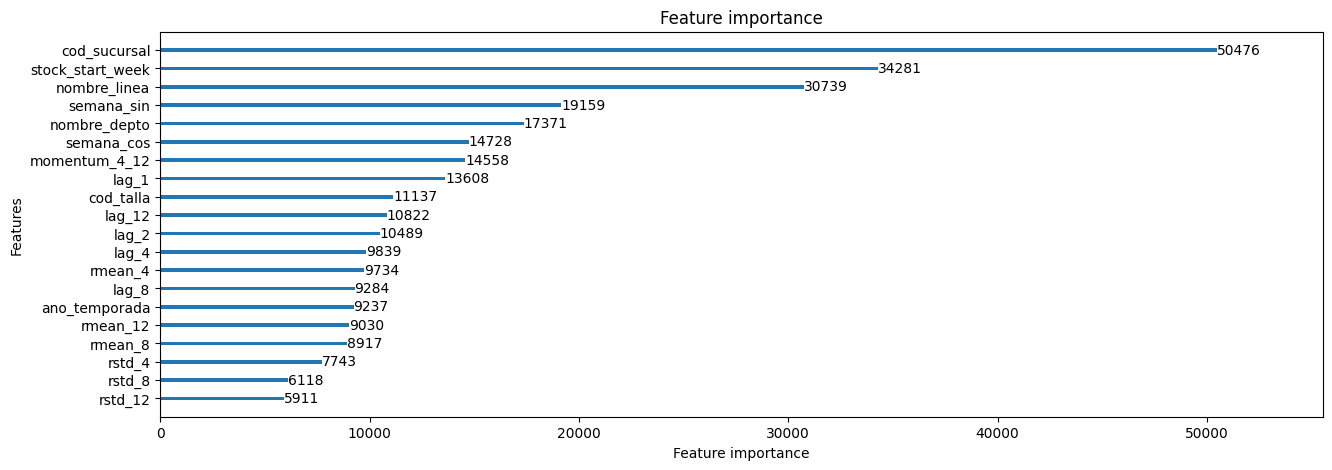

In [ ]:
# ===== Importancia de features =====
ax = lgb.plot_importance(model,max_num_features=20, importance_type="split", figsize=(15,5))
ax.set_title("Feature importance")
ax.grid(False)

plt.show()

In [ ]:
y_pred = model.predict(X_test,num_iteration=best_iter).round(0).astype('int32')

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Empaquetar resultados en un DataFrame para alinear
pred_df = X_test.copy()
pred_df["real"] = y_test.values
pred_df["predicho"] = y_pred
pred_df["week_start_date"] = df.loc[X_test.index, "week_start_date"]

# Asegurar que week_start_date es datetime
pred_df["week_start_date"] = pd.to_datetime(pred_df["week_start_date"])

# Ordenar por fecha
pred_df = pred_df.sort_values("week_start_date")

pred_df['error'] = pred_df['real'] - pred_df['predicho']
pred_df['error_abs'] = pred_df['error'].abs()

In [ ]:
maestro_tallas = load_maestro_producto().collect().to_pandas()[['cod_talla', 'nom_talla']].drop_duplicates().sort_values('cod_talla').reset_index()

In [ ]:
pred_df = pred_df.merge(
    maestro_tallas[['cod_talla', 'nom_talla']],
    on=["cod_talla"],
    how="left"
)

In [ ]:
pred_df = pred_df[pred_df['nombre_temporada'] == "Invierno"]

# Sandbox

In [ ]:
resumen_deptos = pred_df.groupby(['nombre_depto','nombre_linea'], observed = True)[['predicho', 'real', 'error', 'error_abs']].sum().reset_index()

resumen_deptos['wape'] = resumen_deptos['error_abs'] / resumen_deptos['real']

resumen_deptos['bias'] = resumen_deptos['error'] / resumen_deptos['real']

resumen_deptos

,nombre_depto,nombre_linea,predicho,real,error,error_abs,wape,bias
0,Deporte mujer e-comm,Polerones,8166,7146,-1020,5546,0.776099,-0.142737
1,Deporte mujer e-comm,Casacas,15715,20815,5100,11918,0.572568,0.245016
2,Deporte mujer e-comm,Polar,6329,5324,-1005,4483,0.842036,-0.188768
3,Deporte mujer e-comm,Pantalon de buzo,8363,7572,-791,4555,0.601558,-0.104464
4,Sport mujer e-comm,Faldas,11430,6550,-4880,6882,1.050687,-0.745038
...,...,...,...,...,...,...,...,...
235,Sport mujer,Vestidos,109229,97771,-11458,44580,0.455963,-0.117192
236,Sport mujer,Abrigos y chaquetone,44522,34358,-10164,25084,0.730077,-0.295826
237,Zapatillas,Zapatillas importada,144573,152595,8022,65676,0.430394,0.052571
238,Zapatillas,Zapatilla hombre imp,125912,119296,-6616,49222,0.412604,-0.055459


In [ ]:
casos_revisar = pred_df.groupby(['nombre_depto', 'nombre_linea', 'nom_talla', 'cod_sucursal'], observed = True)[['predicho', 'real', 'error', 'error_abs']].sum().reset_index()

casos_revisar['wape'] = casos_revisar['error_abs'] / casos_revisar['real']

casos_revisar['bias'] = casos_revisar['error'] / casos_revisar['real']

casos_revisar.to_excel('../sandbox/casos_revisar.xlsx', index=False)

In [ ]:
casos_revisar.query('wape <= 0.25').sort_values('real', ascending=False)

,nombre_depto,nombre_linea,nom_talla,cod_sucursal,predicho,real,error,error_abs,wape,bias
59127,Juvenil mujer,Lanas,M,767,43022,37866,-5156,7050,0.186183,-0.136164
59234,Juvenil mujer,Lanas,L,767,41609,36987,-4622,7714,0.208560,-0.124963
64293,Lenceria,Pijamas,M,767,38901,36968,-1933,8795,0.237908,-0.052288
59063,Juvenil mujer,Lanas,M,105,20452,18445,-2007,2785,0.150989,-0.108810
57522,Juvenil mujer,Poleras,L,767,19898,18101,-1797,4471,0.247003,-0.099276
...,...,...,...,...,...,...,...,...,...,...
79956,Sport hombres,Camisas manga larga,XL,184,2,2,0,0,0.000000,0.000000
885,Sport mujer e-comm,Poleras manga larga,L,168,2,2,0,0,0.000000,0.000000
338,Deporte mujer e-comm,Casacas,XXL,226,2,2,0,0,0.000000,0.000000
34856,Calzado mujer e-comm,Zapatillas,035,25,1,1,0,0,0.000000,0.000000


In [ ]:
testing = pred_df[['cod_sucursal','nombre_depto', 'nombre_linea','nom_talla','week_start_date','stock_start_week','real','predicho', 'error','error_abs']].copy()

DEPTO = "Juvenil mujer"
LINEA = "BLUSAS MANGA LARGA"
TALLA = "M"
SUCURSAL = 105

testing = testing[
    (testing["nombre_depto"] == DEPTO) &
    (testing["nombre_linea"] == LINEA) &
    (testing["nom_talla"] == TALLA) &
    (testing['cod_sucursal'] == SUCURSAL)
]

len(testing)

30

In [ ]:
testing['SV'] = (testing['stock_start_week']/ (testing['predicho'] / 4)).round(2)

testing

,cod_sucursal,nombre_depto,nombre_linea,nom_talla,week_start_date,stock_start_week,real,predicho,error,error_abs,SV
211280,105,Juvenil mujer,Lanas,M,2025-01-27,0,18,16,2,2,0.00
233163,105,Juvenil mujer,Lanas,M,2025-02-03,176,54,67,-13,13,10.51
323560,105,Juvenil mujer,Lanas,M,2025-02-10,329,57,128,-71,71,10.28
344799,105,Juvenil mujer,Lanas,M,2025-02-17,371,71,195,-124,124,7.61
411958,105,Juvenil mujer,Lanas,M,2025-02-24,501,84,166,-82,82,12.07
507286,105,Juvenil mujer,Lanas,M,2025-03-03,493,92,234,-142,142,8.43
560955,105,Juvenil mujer,Lanas,M,2025-03-10,547,199,395,-196,196,5.54
617752,105,Juvenil mujer,Lanas,M,2025-03-17,680,363,557,-194,194,4.88
699266,105,Juvenil mujer,Lanas,M,2025-03-24,816,624,760,-136,136,4.29
757816,105,Juvenil mujer,Lanas,M,2025-03-31,978,1043,1148,-105,105,3.41


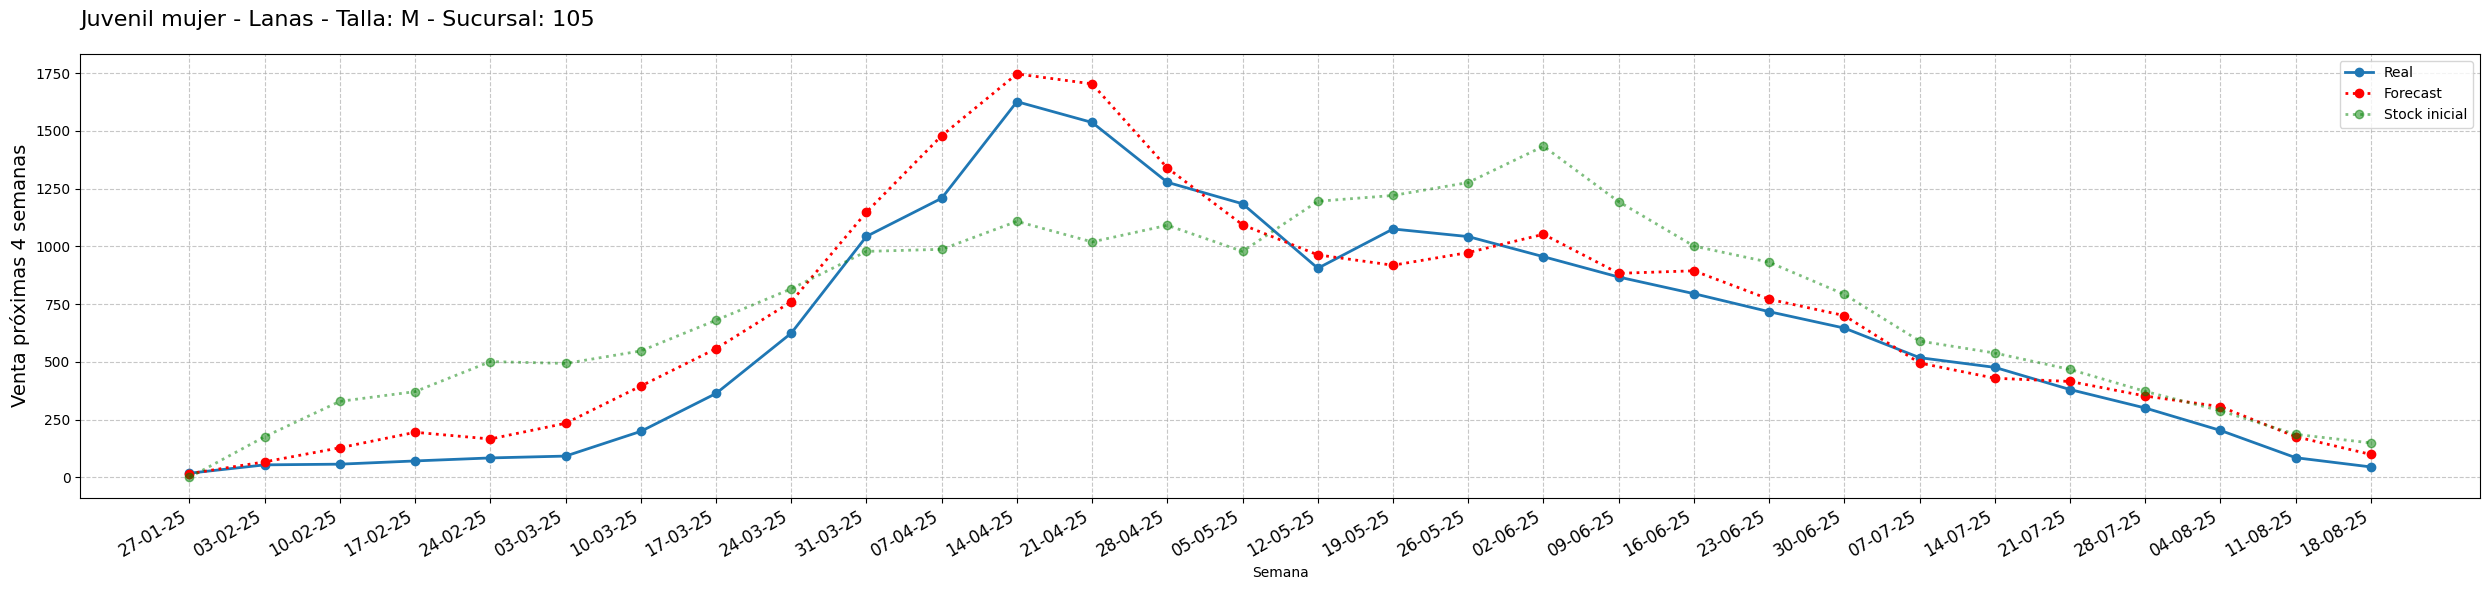

In [ ]:
# Gráfico
plt.figure(figsize=(25, 6))
plt.plot(
    testing["week_start_date"], 
    testing["real"], 
    label="Real",
    linewidth=2, 
    marker='o'
)
plt.plot(
    testing["week_start_date"], 
    testing["predicho"], 
    label="Forecast", 
    linewidth=2, 
    linestyle=':', 
    color='red',
    marker='o'
)

plt.plot(
    testing["week_start_date"], 
    testing["stock_start_week"], 
    label="Stock inicial", 
    linewidth=2, 
    linestyle=':', 
    alpha=0.5,
    color='green',
    marker='o'
)


# Mostrar todas las semanas con año corto
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%y'))
plt.xticks(testing["week_start_date"], rotation=30, ha="right")

plt.xlabel("Semana")
plt.ylabel("Venta próximas 4 semanas", fontsize=14)
plt.xticks(fontsize=12)
plt.title(f"{DEPTO} - {LINEA} - Talla: {TALLA} - Sucursal: {SUCURSAL}", fontsize=16, pad=20, loc = 'left')
plt.legend()
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

all = pred_df.groupby(['week_start_date'], as_index=False, observed=True)[['real','stock_start_week', 'predicho','error','error_abs']].sum()
min_date = data_sales['week_start_date'].min()
all = all[all['week_start_date'] >= min_date]
all['wape'] = all['error_abs'] / all['real']
all['bias'] = all['error'] / all['real']

all = all.iloc[:-3]   # quita las últimas 3 filas

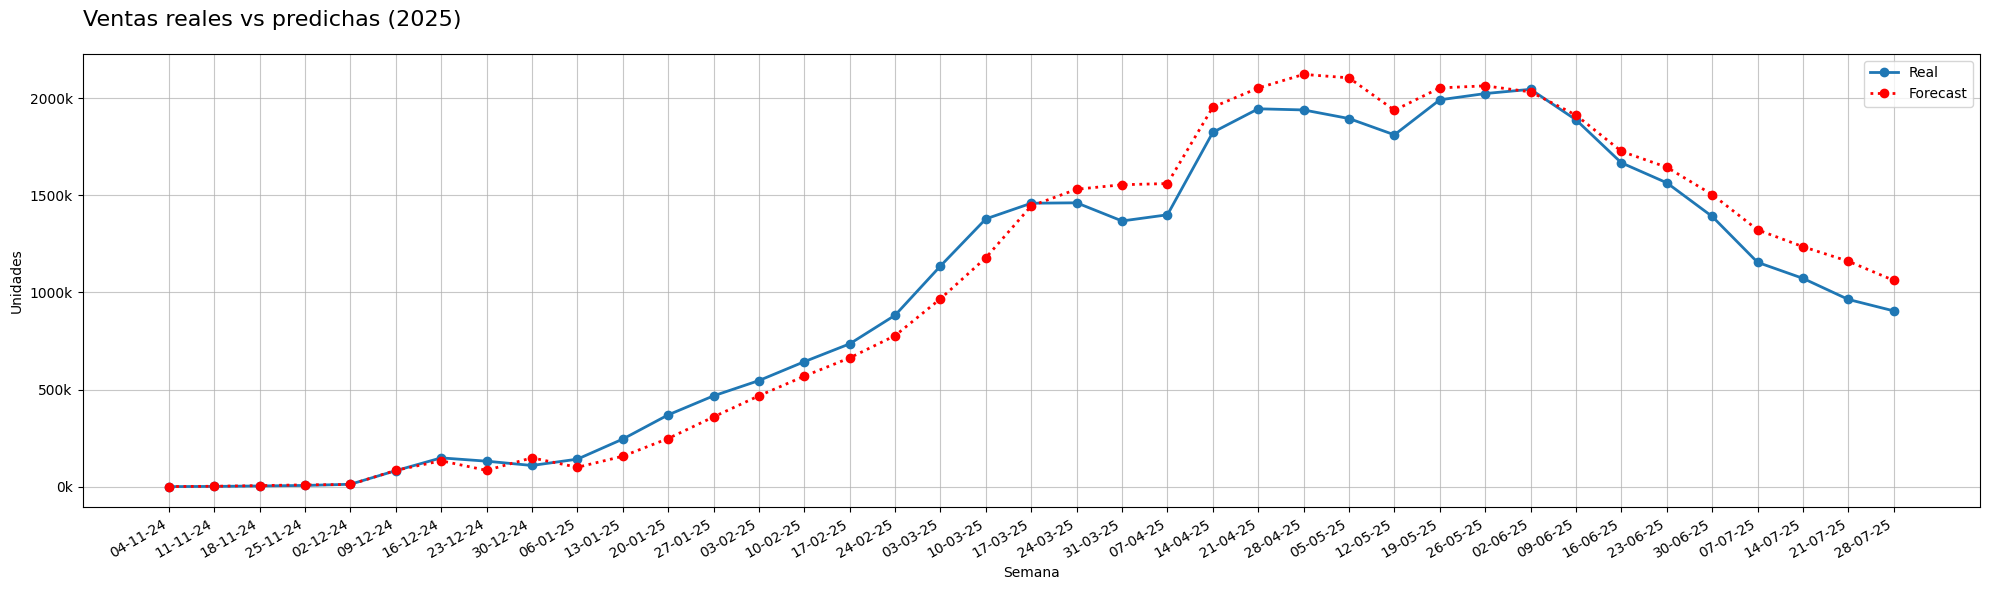

In [ ]:

plt.figure(figsize=(20, 6))
plt.plot(
    all["week_start_date"], 
    all["real"], 
    label="Real",
    linewidth=2, 
    marker='o'
)
plt.plot(
    all["week_start_date"], 
    all["predicho"], 
    label="Forecast", 
    linewidth=2, 
    linestyle=':', 
    color='red',
    marker='o'
)

#plt.plot(
#    all["week_start_date"], 
#    all["stock_start_week"], 
#    label="Stock", 
#    linewidth=2, 
#    linestyle=':', 
#    color='green',
#    marker='o',
#    alpha=0.3
#)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%y'))
plt.xticks(all["week_start_date"], rotation=30, ha="right")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))

plt.xlabel("Semana")
plt.ylabel("Unidades")
plt.title("Ventas reales vs predichas (2025)", fontsize=16, pad=20, loc = 'left')
plt.legend()
plt.grid(linestyle='-', alpha=0.7)
plt.tight_layout()
plt.show()

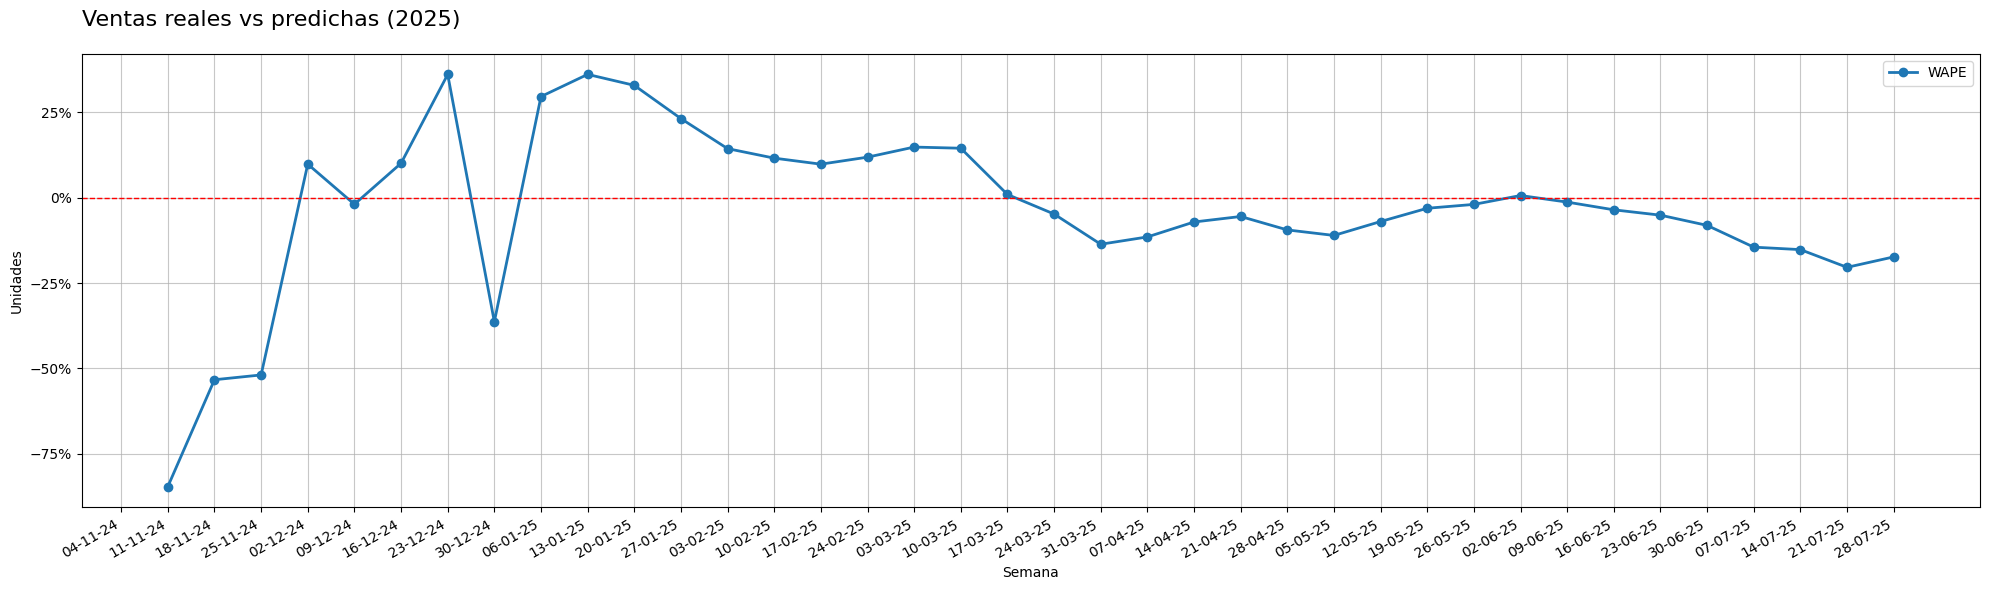

In [ ]:

plt.figure(figsize=(20, 6))
plt.plot(
    all["week_start_date"], 
    all["bias"], 
    label="WAPE",
    linewidth=2, 
    marker='o'
)

plt.axhline(0, color="red", linestyle="--", linewidth=1)


plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%y'))
plt.xticks(all["week_start_date"], rotation=30, ha="right")
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(0.25))

plt.xlabel("Semana")
plt.ylabel("Unidades")
plt.title("Ventas reales vs predichas (2025)", fontsize=16, pad=20, loc = 'left')
plt.legend()
plt.grid(linestyle='-', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
wape = all['error_abs'].sum() / all['real'].sum()
bias = all['error'].sum() / all['real'].sum()

print(wape, bias)

0.3462776674318078 -0.029146295226837718


In [ ]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score


rmse = root_mean_squared_error(pred_df['real'], pred_df['predicho'])  # RMSE
mae = mean_absolute_error(pred_df['real'], pred_df['predicho'])                # MAE
mape = mean_absolute_percentage_error(pred_df['real'], pred_df['predicho'])    # MAPE
r2   = r2_score(pred_df['real'], pred_df['predicho'])                          # R²

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"MAPE: {mape}")
print(f"R²: {r2}")
print(f"WAPE: {wape}")
print(f"Bias: {bias}")

RMSE: 20.7540863174107
MAE: 5.8186987180947565
MAPE: 1258503858853827.0
R²: 0.8224664629254708
WAPE: 0.3462776674318078
Bias: -0.029146295226837718


In [ ]:
pred_df[['cod_sucursal','nombre_depto', 'nombre_linea','cod_talla','week_start_date','real','predicho','error','error_abs']]

,cod_sucursal,nombre_depto,nombre_linea,cod_talla,week_start_date,real,predicho,error,error_abs
1175,767,Juvenil hombres,Pantalones,57,2024-11-04,0,3,-3,3
1176,767,Juvenil hombres,Pantalones,60,2024-11-04,0,3,-3,3
1177,767,Juvenil hombres,Pantalones,63,2024-11-04,0,2,-2,2
1178,767,Juvenil hombres,Pantalones,62,2024-11-04,0,0,0,0
1179,767,Juvenil hombres,Pantalones,59,2024-11-04,0,4,-4,4
...,...,...,...,...,...,...,...,...,...
2503149,55,Sport mujer e-comm,Parkas,103,2025-08-18,0,0,0,0
2503150,103,Ninos,Parkas,15,2025-08-18,0,0,0,0
2503151,32,Lenceria,Pijamas,106,2025-08-18,6,30,-24,24
2503152,23,Juvenil mujer e-comm,Blusas manga larga,105,2025-08-18,0,0,0,0
